<a href="https://colab.research.google.com/github/vishalshahane01/Machine_Learning/blob/main/rea_estate_kagglel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Create Synthetic Construction Data
data = {
    'sq_ft': [1200, 1500, 1100, 1800, 1400, 2200, 1000, 1300, 1600, 1900],
    'price_lakhs': [55, 75, 50, 95, 65, 120, 45, 60, 80, 100],
    'dist_city_km': [5, 10, 2, 15, 7, 20, 3, 8, 12, 18],
    'bedrooms': [2, 3, 2, 3, 2, 4, 2, 2, 3, 3],
    'amenities_score': [7, 8, 9, 6, 8, 5, 9, 7, 8, 6],
    'is_fast_sale': [1, 0, 1, 0, 1, 0, 1, 1, 0, 0] # Target
}

df = pd.DataFrame(data)
X = df.drop('is_fast_sale', axis=1)
y = df['is_fast_sale']

# 2. Scaling (Essential for PCA!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA (Reducing 5 features to 2 Principal Components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained Variance by 2 Components: {np.sum(pca.explained_variance_ratio_):.2%}")

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# 5. Initialize and Train XGBoost
# We use a small max_depth since our dataset is tiny
model = XGBClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, use_label_encoder=False)
model.fit(X_train, y_train)

# 6. Predict and Evaluate
y_pred = model.predict(X_test)
print("\n--- Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Explained Variance by 2 Components: 98.35%

--- Model Performance ---
Accuracy: 0.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       3.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:21:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being

In [2]:
# Create a DataFrame to see the 'Weight' of each original feature in our Components
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)

print("\n--- Feature Loadings (Weights) ---")
print(loadings)


--- Feature Loadings (Weights) ---
                      PC1       PC2
sq_ft            0.463248  0.065408
price_lakhs      0.464234  0.101173
dist_city_km     0.460500  0.001733
bedrooms         0.433258  0.584013
amenities_score -0.412449  0.802752


In [3]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df=pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Machine Learning/DATA/real_estate_dataset.csv')

In [5]:
df

,url,beds,city,date,size,type,baths,price,neighborhood
0,https://www.99acres.com/residential-land-plot-...,0,Bangalore,2025-02-19,799-1258 sqft,Residential land / Plot,0,2317000.0,Jigani
1,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,Bangalore,2025-02-19,1085 sqft,2 BHK Flat,2,12500000.0,Tumkur Road
2,https://www.99acres.com/sumadhura-capitol-resi...,3,Bangalore,2025-02-19,1525-2150 sqft,"3, 4 BHK Apartment",0,23200000.0,Whitefield
3,https://www.99acres.com/provident-botanico-sou...,2,Bangalore,2025-02-19,658-1003 sqft,"2, 3 BHK Apartment",0,889000.0,Soukya Road
4,https://www.99acres.com/kvg-superior-kalkere-b...,2,Bangalore,2025-02-19,1179-1449 sqft,"2, 3 BHK Apartment",0,6483000.0,Kalkere
...,...,...,...,...,...,...,...,...,...
282,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,Pune,2025-01-19,840 sqft,Residential apartment,3,10000000.0,Manjari Khurd
283,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,Pune,2025-02-13,690 sqft,Residential apartment,2,6500000.0,Punawale
284,https://www.99acres.com/6-bhk-bedroom-independ...,6,Pune,2025-01-19,840 sqft,Independent House/Villa,6,13500000.0,Katraj
285,https://www.99acres.com/1-bhk-bedroom-apartmen...,1,Pune,2025-02-17,640 sqft,Residential apartment,1,3500000.0,Kirkatwadi


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   url           287 non-null    object 
 1   beds          287 non-null    int64  
 2   city          287 non-null    object 
 3   date          287 non-null    object 
 4   size          287 non-null    object 
 5   type          287 non-null    object 
 6   baths         287 non-null    int64  
 7   price         287 non-null    float64
 8   neighborhood  287 non-null    object 
dtypes: float64(1), int64(2), object(6)
memory usage: 20.3+ KB


In [7]:
df['size'].unique()

array(['799-1258 sqft', '1085 sqft', '1525-2150 sqft', '658-1003 sqft',
       '1179-1449 sqft', '1199-2484 sqft', '794-1923 sqft', '0 sqft',
       '1006-1636 sqft', '1335-2700 sqft', '6050 sqft', '4200 sqft',
       '9000 sqft', '967.58 - 1,751.41 sqft', '1942 sqft', '2562 sqft',
       '1805 sqft', '4500 sqft', '3150 sqft', '3240 sqft', '2600 sqft',
       '1800 sqft', '165 sqft', '2304 sqft', '230 sqft', '350 sqft',
       '1368 sqft', '1450 sqft', '1422 sqft', '1503 sqft', '1260 sqft',
       '990 - 1245 sqft', '1630 - 2190 sqft', '823 - 1117 sqft',
       '2195 - 2650 sqft', '895 - 1050 sqft', '1158 - 1474 sqft',
       '3503 - 6226 sqft', '3049 sqft', '10454 sqft', '1388 sqft',
       '1375 sqft', '1350 sqft', '940 sqft', '1000 sqft', '35790 sqft',
       '3229 sqft', '4843 sqft', '1200-2000 sqft', '2179 sqft',
       '758.34 - 945.73 sqft', '1185 - 1610 sqft', '1691 - 2543 sqft',
       '1527 - 2078 sqft', '2160 - 3190 sqft', '923 - 3097 sqft',
       '1877 - 3038 sqft', '704.7

In [8]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
print("Converted 'date' column to datetime type, coercing errors to NaT.")

Converted 'date' column to datetime type, coercing errors to NaT.


In [9]:
def extract_sq_ft(size_str):
    if isinstance(size_str, str) and 'sqft' in size_str:
        size_str = size_str.replace(' sqft', '').replace(',', '') # Remove commas
        if '-' in size_str:
            lower, upper = map(float, size_str.split('-'))
            return (lower + upper) / 2
        else:
            try:
                return float(size_str)
            except ValueError:
                return np.nan # Handle cases where it still can't convert
    return np.nan # Handle cases where 'sqft' is not present or other formats

if 'size' in df.columns:
    df['size_sq_ft'] = df['size'].apply(extract_sq_ft)
    df = df.drop('size', axis=1) # Drop the original 'size' column
    print("Extracted numerical 'size_sq_ft' column and dropped original 'size' column.")
    display(df.head())
elif 'size_sq_ft' not in df.columns:
    print("Warning: 'size' column not found, and 'size_sq_ft' was not created.")
else:
    print("'size_sq_ft' column already exists and 'size' column not found, no action taken.")

Extracted numerical 'size_sq_ft' column and dropped original 'size' column.


,url,beds,city,date,type,baths,price,neighborhood,size_sq_ft
0,https://www.99acres.com/residential-land-plot-...,0,Bangalore,2025-02-19,Residential land / Plot,0,2317000.0,Jigani,1028.5
1,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,Bangalore,2025-02-19,2 BHK Flat,2,12500000.0,Tumkur Road,1085.0
2,https://www.99acres.com/sumadhura-capitol-resi...,3,Bangalore,2025-02-19,"3, 4 BHK Apartment",0,23200000.0,Whitefield,1837.5
3,https://www.99acres.com/provident-botanico-sou...,2,Bangalore,2025-02-19,"2, 3 BHK Apartment",0,889000.0,Soukya Road,830.5
4,https://www.99acres.com/kvg-superior-kalkere-b...,2,Bangalore,2025-02-19,"2, 3 BHK Apartment",0,6483000.0,Kalkere,1314.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   url           287 non-null    object        
 1   beds          287 non-null    int64         
 2   city          287 non-null    object        
 3   date          202 non-null    datetime64[ns]
 4   type          287 non-null    object        
 5   baths         287 non-null    int64         
 6   price         287 non-null    float64       
 7   neighborhood  287 non-null    object        
 8   size_sq_ft    227 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 20.3+ KB


In [11]:
df['size_sq_ft'].unique()

array([1.028500e+03, 1.085000e+03, 1.837500e+03, 8.305000e+02,
       1.314000e+03, 1.841500e+03, 1.358500e+03, 0.000000e+00,
       1.321000e+03, 2.017500e+03, 6.050000e+03, 4.200000e+03,
       9.000000e+03, 1.359495e+03, 1.942000e+03, 2.562000e+03,
       1.805000e+03, 4.500000e+03, 3.150000e+03, 3.240000e+03,
       2.600000e+03, 1.800000e+03, 1.650000e+02, 2.304000e+03,
       2.300000e+02, 3.500000e+02, 1.368000e+03, 1.450000e+03,
       1.422000e+03, 1.503000e+03, 1.260000e+03, 1.117500e+03,
       1.910000e+03, 9.700000e+02, 2.422500e+03, 9.725000e+02,
       1.316000e+03, 4.864500e+03, 3.049000e+03, 1.045400e+04,
       1.388000e+03, 1.375000e+03, 1.350000e+03, 9.400000e+02,
       1.000000e+03, 3.579000e+04, 3.229000e+03, 4.843000e+03,
       1.600000e+03, 2.179000e+03, 8.520350e+02, 1.397500e+03,
       2.117000e+03, 1.802500e+03, 2.675000e+03, 2.010000e+03,
       2.457500e+03, 8.569700e+02, 9.525500e+03, 1.530000e+03,
       2.583000e+03, 1.918350e+03, 2.916000e+03, 4.8780

In [12]:
df_clean_1 = df.drop('url', axis=1)

In [13]:
df_clean_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   beds          287 non-null    int64         
 1   city          287 non-null    object        
 2   date          202 non-null    datetime64[ns]
 3   type          287 non-null    object        
 4   baths         287 non-null    int64         
 5   price         287 non-null    float64       
 6   neighborhood  287 non-null    object        
 7   size_sq_ft    227 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 18.1+ KB


In [14]:
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Start with a fresh copy of the original DataFrame to ensure consistent preprocessing
df_processed = df.copy()

# 1. Drop the URL column
if 'url' in df_processed.columns:
    df_processed = df_processed.drop('url', axis=1)

# 2. Handle 'size' column and convert to 'size_sq_ft'
# Ensure 'date' column is handled as per 7346b7f5 and 'size' as per f77e9aed
# Re-implementing extract_sq_ft function to be safe if `size` column still exists or needs re-processing
def extract_sq_ft(size_str):
    if isinstance(size_str, str) and 'sqft' in size_str:
        size_str = size_str.replace(' sqft', '').replace(',', '') # Remove commas
        if '-' in size_str:
            lower, upper = map(float, size_str.split('-'))
            return (lower + upper) / 2
        else:
            try:
                return float(size_str)
            except ValueError:
                return np.nan
    elif isinstance(size_str, str) and ('sq.ft.' in size_str or 'sq.ft' in size_str): # Handle 'sq.ft.' variants
        size_str = size_str.replace(' sq.ft.', '').replace(' sq.ft', '').replace(',', '')
        if '-' in size_str:
            lower, upper = map(float, size_str.split('-'))
            return (lower + upper) / 2
        else:
            try:
                return float(size_str)
            except ValueError:
                return np.nan
    return np.nan

if 'size' in df_processed.columns:
    df_processed['size_sq_ft'] = df_processed['size'].apply(extract_sq_ft)
    df_processed = df_processed.drop('size', axis=1)

# Fill NaNs in 'size_sq_ft' after extraction
df_processed['size_sq_ft'] = df_processed['size_sq_ft'].fillna(df_processed['size_sq_ft'].median())

# 3. Drop the 'date' column (CatBoost cannot handle datetime objects directly for simple input)
if 'date' in df_processed.columns:
    df_processed = df_processed.drop('date', axis=1)

# 4. Label Encode categorical features
le = LabelEncoder()
categorical_cols = ['city', 'type', 'neighborhood']

for col in categorical_cols:
    if col in df_processed.columns: # Check if column exists before encoding
        df_processed[col] = le.fit_transform(df_processed[col])

# Separate features (X) and target (y)
X = df_processed.drop('price', axis=1)
y = df_processed['price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train CatBoostRegressor
model_catboost = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, random_state=42, verbose=0)
model_catboost.fit(X_train, y_train)

y_pred_catboost = model_catboost.predict(X_test)

mae_catboost = mean_absolute_error(y_test, y_pred_catboost)
r2_catboost = r2_score(y_test, y_pred_catboost)

print(f"--- CatBoostRegressor Model Evaluation (using re-preprocessed data) ---")
print(f"Mean Absolute Error: {mae_catboost:.2f}")
print(f"R-Squared Score: {r2_catboost:.2f}")

--- CatBoostRegressor Model Evaluation (using re-preprocessed data) ---
Mean Absolute Error: 21252790.84
R-Squared Score: -2.87


In [15]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Drop the URL (Noise)
df_clean = df.drop('url', axis=1)

# 2. Handle Missing Values (The Construction Logic)
# For size_sq_ft, we'll use the MEDIAN size so outliers don't skew it
df_clean['size_sq_ft'] = df_clean['size_sq_ft'].fillna(df_clean['size_sq_ft'].median())

# For date, if it's missing, let's just drop the column for now as
# price prediction is usually based on features, not the specific day.
df_clean = df_clean.drop('date', axis=1)

# 3. Handle Categorical Data (Encoding)
# We use LabelEncoder to turn "Nashik", "Mumbai", etc. into 0, 1, 2...
le = LabelEncoder()
categorical_cols = ['city', 'type', 'neighborhood']

for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# 4. Final Check
print("--- Cleaned Data Info ---")
print(df_clean.info())
print("\nFirst 5 rows of encoded data:")
print(df_clean.head())

--- Cleaned Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   beds          287 non-null    int64  
 1   city          287 non-null    int64  
 2   type          287 non-null    int64  
 3   baths         287 non-null    int64  
 4   price         287 non-null    float64
 5   neighborhood  287 non-null    int64  
 6   size_sq_ft    287 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 15.8 KB
None

First 5 rows of encoded data:
   beds  city  type  baths       price  neighborhood  size_sq_ft
0     0     1    44      0   2317000.0            55      1028.5
1     2     1     6      2  12500000.0           202      1085.0
2     3     1    18      0  23200000.0           215      1837.5
3     2     1     9      0    889000.0           180       830.5
4     2     1     9      0   6483000.0            57      1314.0


--- Correlation with Price ---
price           1.000000
size_sq_ft      0.132497
type            0.128700
baths           0.034577
beds            0.020138
neighborhood   -0.020400
city           -0.077072
Name: price, dtype: float64


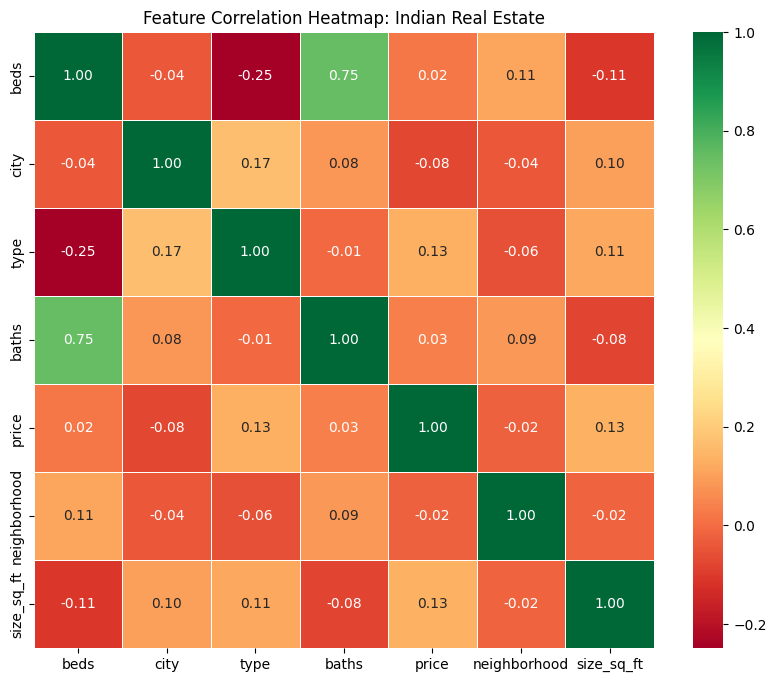

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the correlation matrix
# This tells us how every column relates to 'price' (from -1 to 1)
corr_matrix = df_clean.corr()

# 2. Focus specifically on the relationship with 'Price'
price_correlation = corr_matrix['price'].sort_values(ascending=False)
print("--- Correlation with Price ---")
print(price_correlation)

# 3. Visualize it with a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap: Indian Real Estate')
plt.show()

In [17]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Prepare Features (X) and Target (y)
# We use our 'df_final' which has the PCA 'living_capacity' and no redundant columns
X = df_clean.drop('price', axis=1)
y = df_clean['price']

# 2. Split the Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the XGBoost Regressor
# n_estimators: Number of trees
# learning_rate: How much each tree corrects the previous one (0.1 is standard)
# max_depth: How deep each tree grows (prevents overfitting)
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# 4. Train the Model
model.fit(X_train, y_train)

# 5. Make Predictions on the Test Set
y_pred = model.predict(X_test)

# 6. Evaluate the Performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Evaluation ---")
print(f"Mean Absolute Error: {mae:.2f} Lakhs")
print(f"R-Squared Score: {r2:.2f}") # Closer to 1.0 is better

--- Model Evaluation ---
Mean Absolute Error: 28240285.04 Lakhs
R-Squared Score: -14.24


In [18]:
df['price'].unique()

array([2.317e+06, 1.250e+07, 2.320e+07, 8.890e+05, 6.483e+06, 1.500e+07,
       7.518e+06, 3.980e+07, 1.110e+07, 1.570e+07, 2.000e+08, 4.010e+07,
       2.495e+08, 5.280e+07, 6.900e+07, 4.160e+07, 3.050e+07, 4.500e+07,
       4.490e+07, 3.400e+07, 1.650e+07, 1.160e+07, 1.000e+07, 2.000e+07,
       2.500e+07, 5.500e+06, 6.900e+06, 5.800e+06, 8.000e+06, 4.676e+06,
       3.780e+06, 4.940e+06, 9.454e+06, 7.501e+06, 1.870e+07, 3.133e+06,
       6.947e+06, 2.980e+07, 1.200e+07, 3.960e+07, 7.500e+06, 7.000e+06,
       5.000e+06, 1.500e+06, 3.500e+07, 5.500e+07, 9.000e+07, 1.559e+06,
       1.800e+07, 7.900e+06, 8.938e+06, 8.286e+06, 2.060e+07, 1.470e+07,
       1.180e+07, 1.400e+07, 7.200e+06, 0.000e+00, 6.500e+06, 1.120e+07,
       2.540e+07, 1.190e+07, 1.070e+07, 7.014e+06, 1.220e+07, 4.000e+06,
       6.300e+06, 1.100e+06, 1.350e+07, 3.600e+06, 5.300e+07, 5.460e+06,
       3.000e+06, 1.998e+06, 7.678e+06, 1.240e+06, 2.510e+07, 9.480e+05,
       2.300e+07, 8.800e+05, 1.859e+06, 8.232e+06, 

In [19]:
from sklearn.decomposition import PCA

# 1. Isolate the highly correlated features
capacity_data = df_clean[['beds', 'baths']]

# 2. Use PCA to compress them into 1 feature
pca_capacity = PCA(n_components=1)
df_clean['living_capacity'] = pca_capacity.fit_transform(capacity_data)

# 3. Drop the old redundant columns
df_final = df_clean.drop(['beds', 'baths'], axis=1)

print("New Feature 'living_capacity' created. Old features dropped.")
print(df_final.head())

New Feature 'living_capacity' created. Old features dropped.
   city  type       price  neighborhood  size_sq_ft  living_capacity
0     1    44   2317000.0            55      1028.5        -2.603619
1     1     6  12500000.0           202      1085.0         0.224806
2     1    18  23200000.0           215      1837.5        -0.485161
3     1     9    889000.0           180       830.5        -1.191313
4     1     9   6483000.0            57      1314.0        -1.191313


In [20]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Prepare Features (X) and Target (y)
# We use our 'df_final' which has the PCA 'living_capacity' and no redundant columns
X = df_final.drop('price', axis=1)
y = df_final['price']

# 2. Split the Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the XGBoost Regressor
# n_estimators: Number of trees
# learning_rate: How much each tree corrects the previous one (0.1 is standard)
# max_depth: How deep each tree grows (prevents overfitting)
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# 4. Train the Model
model.fit(X_train, y_train)

# 5. Make Predictions on the Test Set
y_pred = model.predict(X_test)

# 6. Evaluate the Performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Evaluation ---")
print(f"Mean Absolute Error: {mae:.2f} Lakhs")
print(f"R-Squared Score: {r2:.2f}") # Closer to 1.0 is better

--- Model Evaluation ---
Mean Absolute Error: 27050399.65 Lakhs
R-Squared Score: -14.07


In [21]:
np.log1p(df_clean['price'])

,price
0,14.655784
1,16.341239
2,16.959663
3,13.697854
4,15.684694
...,...
282,16.118096
283,15.687313
284,16.418200
285,15.068274


In [22]:
df_clean['price'] = np.log1p(df_clean['price'])


In [23]:
df_clean.head()

,beds,city,type,baths,price,neighborhood,size_sq_ft,living_capacity
0,0,1,44,0,14.655784,55,1028.5,-2.603619
1,2,1,6,2,16.341239,202,1085.0,0.224806
2,3,1,18,0,16.959663,215,1837.5,-0.485161
3,2,1,9,0,13.697854,180,830.5,-1.191313
4,2,1,9,0,15.684694,57,1314.0,-1.191313


In [24]:
# 1. Prepare Features (X) and Target (y)
# We use our 'df_final' which has the PCA 'living_capacity' and no redundant columns
X = df_clean.drop('price', axis=1)
y = df_clean['price']

# 2. Split the Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the XGBoost Regressor
# n_estimators: Number of trees
# learning_rate: How much each tree corrects the previous one (0.1 is standard)
# max_depth: How deep each tree grows (prevents overfitting)
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# 4. Train the Model
model.fit(X_train, y_train)

# 5. Make Predictions on the Test Set
y_pred = model.predict(X_test)

# 6. Evaluate the Performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Evaluation ---")
print(f"Mean Absolute Error: {mae:.2f} Lakhs")
print(f"R-Squared Score: {r2:.2f}") # Closer to 1.0 is better

--- Model Evaluation ---
Mean Absolute Error: 1.75 Lakhs
R-Squared Score: -0.07


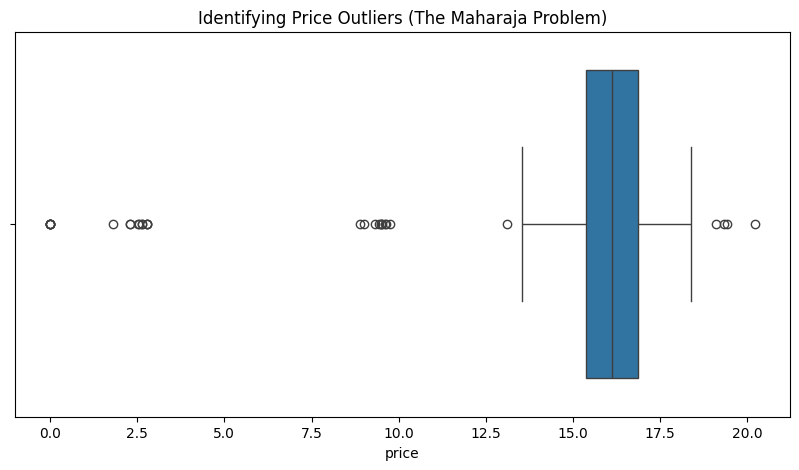

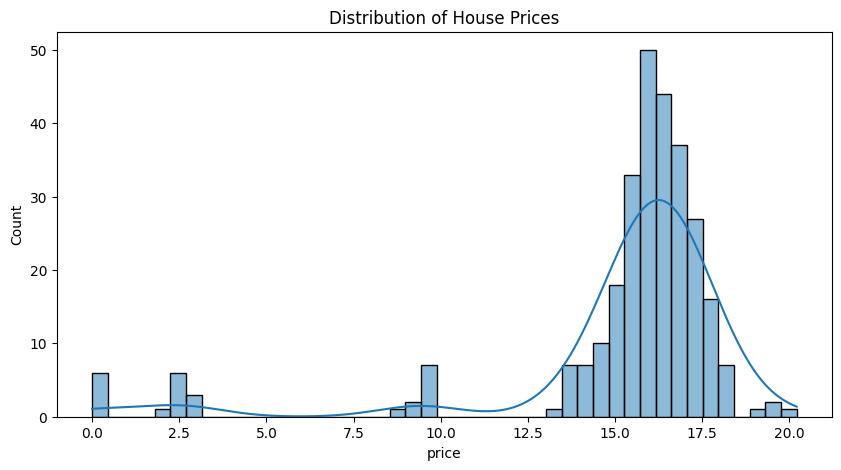

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Boxplot to see the 'Diamonds' (Outliers)
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_clean['price'])
plt.title('Identifying Price Outliers (The Maharaja Problem)')
plt.show()

# 2. Histogram to see the 'Skew'
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['price'], kde=True)
plt.title('Distribution of House Prices')
plt.show()

In [26]:
# 1. Calculate the Quantiles
lower_limit = df_clean['price'].quantile(0.05)
upper_limit = df_clean['price'].quantile(0.95)

# 2. Filter the data (Keeping only the middle 90%)
df_filtered = df_clean[(df_clean['price'] > lower_limit) & (df_clean['price'] < upper_limit)]

print(f"Original Rows: {len(df_clean)}")
print(f"Filtered Rows: {len(df_filtered)}")
print(f"Price Range: {df_filtered['price'].min()} to {df_filtered['price'].max()} Lakhs")

Original Rows: 287
Filtered Rows: 256
Price Range: 8.888894669371593 to 17.78580249038432 Lakhs


In [27]:
from sklearn.model_selection import cross_val_score

# 1. Initialize the model with better 'Regularization'
model_robust = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    reg_lambda=1, # L2 Regularization (Ridge)
    reg_alpha=0.5  # L1 Regularization (Lasso)
)

# 2. Perform 5-Fold Cross Validation
cv_scores = cross_val_score(model_robust, X, y, cv=5, scoring='r2')

print(f"All CV R2 Scores: {cv_scores}")
print(f"Average R2 Score: {cv_scores.mean():.4f}")

All CV R2 Scores: [-11.58432489  -0.46316358  -2.3702856  -13.05433005  -0.6455398 ]
Average R2 Score: -5.6235
